In [8]:
import pandas as pd

df = pd.read_csv("../data/processed/final_dataset.csv", parse_dates=["timestamp"])
df = df.set_index("timestamp")

In [60]:
import numpy as np

df["hour"] = df.index.hour
df["dayofweek"] = df.index.dayofweek
df["month"] = df.index.month

df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)

df["lag_24"] = df["price"].shift(24)
df["lag_48"] = df["price"].shift(48)
df["lag_168"] = df["price"].shift(168)

df["rolling_mean_24"] = df["price"].shift(1).rolling(24).mean()
df["rolling_std_24"] = df["price"].shift(1).rolling(24).std()

df["rolling_mean_48"] = df["price"].shift(1).rolling(48).mean()
df["rolling_mean_168"] = df["price"].shift(1).rolling(168).mean()

df = df.dropna()

In [61]:
train = df[: "2025-12-31"]
test = df["2026-01-01":]

In [62]:
features = [
    "hour", "dayofweek", "month",
    "hour_sin", "hour_cos",
    "lag_24", "lag_48", "lag_168",
    "rolling_mean_24", "rolling_std_24", "rolling_mean_48", "rolling_mean_168",
    "load", "wind", "solar"
]

X_train = train[features]
y_train = train["price"]

X_test = test[features]
y_test = test["price"]

In [63]:
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.03,
    max_depth=6,
    subsample=0.75,
    colsample_bytree=0.75,
    random_state=42
)

model.fit(X_train, y_train)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.75
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_met

In [64]:
pred = model.predict(X_test)

In [65]:
from sklearn.metrics import mean_absolute_error

mae_xgb = mean_absolute_error(y_test, pred)
mae_baseline = mean_absolute_error(y_test, test["lag_24"])

print("XGBoost MAE:", mae_xgb)
print("Baseline MAE:", mae_baseline)

XGBoost MAE: 12.530797554234663
Baseline MAE: 22.043645833333336


## Final Stage - Prediction for 10 Feb 2026

In [66]:
target_date = "2026-02-10"

In [67]:
import pandas as pd

future_hours = pd.date_range(
    start="2026-02-10 00:00:00",
    end="2026-02-10 23:00:00",
    freq="h"
)

future_df = pd.DataFrame({"timestamp": future_hours})

In [68]:
import numpy as np

future_df["hour"] = future_df["timestamp"].dt.hour
future_df["dayofweek"] = future_df["timestamp"].dt.dayofweek
future_df["month"] = future_df["timestamp"].dt.month

future_df["hour_sin"] = np.sin(2 * np.pi * future_df["hour"] / 24)
future_df["hour_cos"] = np.cos(2 * np.pi * future_df["hour"] / 24)

In [69]:
last_data = df.copy()

future_df["lag_24"] = last_data["price"].iloc[-24:].values
future_df["lag_48"] = last_data["price"].iloc[-48:-24].values
future_df["lag_168"] = last_data["price"].iloc[-168:-144].values

In [70]:
future_df["rolling_mean_24"] = last_data["price"].iloc[-24:].mean()
future_df["rolling_std_24"] = last_data["price"].iloc[-24:].std()

future_df["rolling_mean_48"] = last_data["price"].iloc[-48:].mean()
future_df["rolling_mean_168"] = last_data["price"].iloc[-168:].mean()


In [71]:
future_df["load"] = last_data["load"].iloc[-24:].values
future_df["wind"] = last_data["wind"].iloc[-24:].values
future_df["solar"] = last_data["solar"].iloc[-24:].values

In [72]:
pred_final = model.predict(future_df[features])
future_df["predicted_price"] = pred_final

In [77]:
final_predictions = future_df[["timestamp", "predicted_price"]]

future_df[["timestamp", "predicted_price"]]


,timestamp,predicted_price
0,2026-02-10 00:00:00,111.268753
1,2026-02-10 01:00:00,110.367004
2,2026-02-10 02:00:00,108.517662
3,2026-02-10 03:00:00,109.264320
4,2026-02-10 04:00:00,111.703003
5,2026-02-10 05:00:00,120.089371
6,2026-02-10 06:00:00,138.346710
7,2026-02-10 07:00:00,180.256622
8,2026-02-10 08:00:00,203.752213
9,2026-02-10 09:00:00,181.672760


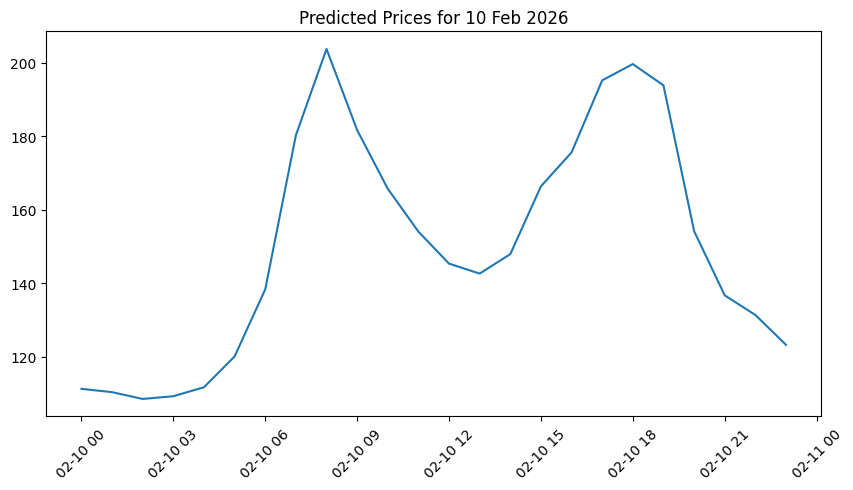

In [74]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(future_df["timestamp"], future_df["predicted_price"])
plt.title("Predicted Prices for 10 Feb 2026")
plt.xticks(rotation=45)
plt.show()

In [78]:
final_predictions.to_csv(
    "../outputs/predictions/final_predictions_2026_02_10.csv",
    index=False
)

## Validation on Actual Data (10 Feb 2026)

In [82]:
actual_2026 = pd.read_csv("../data/raw/day_ahead_prices_2026_02_10.csv", sep=";")

actual_2026 = actual_2026[[
    "Start date",
    "Germany/Luxembourg [€/MWh] Calculated resolutions"
]]

actual_2026.columns = ["timestamp", "actual_price"]
actual_2026["timestamp"] = pd.to_datetime(actual_2026["timestamp"])

C:\Users\ankit\AppData\Local\Temp\ipykernel_10216\3602458375.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  actual_2026["timestamp"] = pd.to_datetime(actual_2026["timestamp"])


In [83]:
final_df = pd.merge(
    final_predictions,
    actual_2026,
    on="timestamp",
    how="inner"
)

In [84]:
from sklearn.metrics import mean_absolute_error

mae_final = mean_absolute_error(
    final_df["actual_price"],
    final_df["predicted_price"]
)

print("Final Forecast MAE:", mae_final)

Final Forecast MAE: 33.44921274820963


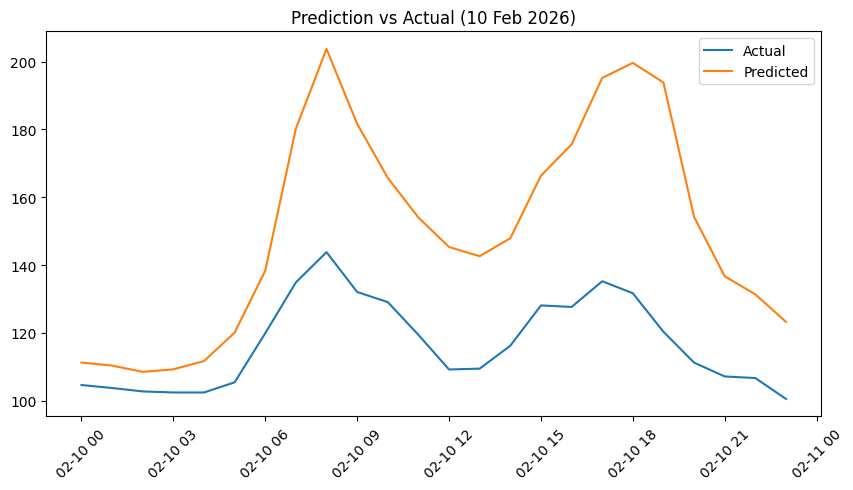

In [85]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(final_df["timestamp"], final_df["actual_price"], label="Actual")
plt.plot(final_df["timestamp"], final_df["predicted_price"], label="Predicted")
plt.legend()
plt.xticks(rotation=45)
plt.title("Prediction vs Actual (10 Feb 2026)")
plt.show()

While the model achieved strong performance on historical test data, the final prediction error increased when forecasting a full unseen day. This is mainly due to the lack of accurate future values for external variables such as load, wind, and solar, which were approximated using previous-day values. This highlights a key real-world challenge in electricity price forecasting: the dependence on reliable external forecasts.

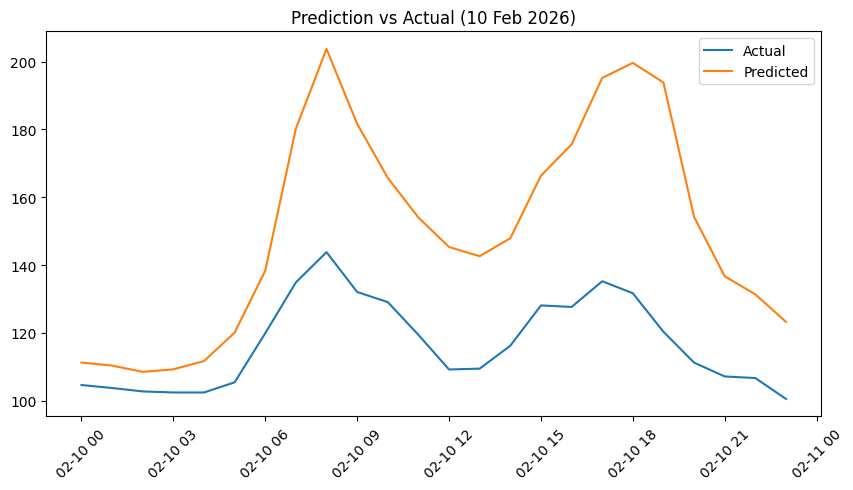

In [90]:
import os

os.makedirs("../outputs/figures", exist_ok=True)

plt.figure(figsize=(10,5))
plt.plot(final_df["timestamp"], final_df["actual_price"], label="Actual")
plt.plot(final_df["timestamp"], final_df["predicted_price"], label="Predicted")
plt.legend()
plt.xticks(rotation=45)
plt.title("Prediction vs Actual (10 Feb 2026)")

plt.savefig("../outputs/figures/final_prediction_vs_actual.png", bbox_inches="tight")
plt.show()

In [91]:
os.makedirs("../outputs/predictions", exist_ok=True)

final_df.to_csv(
    "../outputs/predictions/final_predictions_vs_actual.csv",
    index=False
)